# Test xarray refactor

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import napari

from gulp2p.preproc import utils
from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.trial import Trial

from gulp2p.config import CONFIG_DICT

## Select Data

In [2]:
# tiff_path = utils.select_file_path(initialdir=Path(r"Z:\2PImaging\Kerstin\MIMS"))

tiff_path = Path('Z:/2PImaging/Kerstin/MIMS/20240117/20240117_DR019xiGluSnFr_Fly1_00004.tif')

print(tiff_path)

Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00004.tif


## Tiff

In [3]:
# Create Tiff object
tiff = Tiff(tiff_path)

In [4]:
# dims = tuple(dim for dim in tiff.metadata['dimension_order'])
# tiff.xarray_stack = xr.DataArray(tiff.stack, dims=dims)

In [5]:
# tiff.xarray_stack.attrs["long_name"] = "Change in florescence over baseline"

In [6]:
# tiff.xarray_stack.isel(T=0, Z=3).plot()

In [7]:
# print(tiff.metadata['SizeC'] 
# * tiff.metadata['SizeZ']
# * tiff.metadata['SizeT'] 
# * tiff.metadata['frame_interval'] + (tiff.metadata['flyback_time'] * tiff.metadata['SizeZ']))

# print(tiff.metadata['SizeT'] / tiff.metadata['volume_rate'])

In [8]:
# tiff.metadata['flyback_time'] * tiff.metadata['SizeT']

In [9]:
tiff.metadata

{'laser_power': 0.35,
 'SizeC': 1,
 'discard_fb_frames': True,
 'flyback_time': 0.001,
 'num_fb_frames': 1,
 'SizeY': 256,
 'SizeX': 128,
 'frame_interval': 0.0171767,
 'frame_rate': 58.2183,
 'volume_rate': 7.27729,
 'zoom_factor': 2.8,
 'pixel_bin_factor': 1,
 'SizeZ': 8,
 'SizeT': 2995,
 'original_dim_order': 'TYX',
 'dimension_order': 'TZCYX',
 'length': 411.55373199999997,
 'date': datetime.datetime(2024, 1, 17, 10, 48, 9, 728358),
 'file_size': 1627383100,
 'pixel_width': 2.0421884134048462,
 'width_unit': 'um',
 'pixel_height': 2.0421884134048462,
 'height_unit': 'um'}

In [33]:
tiff.stack

<xarray.DataArray (T: 2995, Z: 7, C: 1, Y: 256, X: 128)>
array([[[[[133, 131, 141, ..., 129, 130, 125],
          [144, 130, 123, ..., 122, 138, 123],
          [130, 138, 130, ..., 129, 127, 136],
          ...,
          [127, 130, 111, ..., 131, 123, 139],
          [135, 127, 132, ..., 136, 122, 129],
          [137, 127, 138, ..., 116, 155, 140]]],


        [[[125, 135, 124, ..., 135, 477, 256],
          [209, 128, 132, ..., 132, 145, 140],
          [138, 130, 124, ..., 135, 135, 119],
          ...,
          [127, 135, 118, ..., 133, 123, 126],
          [129, 138, 133, ..., 270, 139, 137],
          [233, 136, 122, ..., 130, 117, 129]]],


        [[[117, 132, 132, ..., 176, 138, 135],
          [137, 125, 138, ..., 119, 126, 145],
...
          [137, 125, 121, ..., 131, 115, 119],
          [129, 128, 123, ..., 125, 117, 125]]],


        [[[133, 106, 129, ..., 137, 130, 115],
          [125, 134, 112, ..., 145, 115, 113],
          [131, 115, 121, ..., 135, 111, 116],
          ...,
          [131, 126, 143, ..., 132, 129, 120],
          [122, 117, 136, ..., 133, 108, 132],
          [133, 134, 127, ..., 134, 139, 116]]],


        [[[133, 121, 120, ..., 115, 137, 118],
          [130, 131, 130, ..., 128, 137, 125],
          [123, 119, 127, ..., 130, 128, 115],
          ...,
          [131, 131, 129, ..., 141, 130, 135],
          [128, 116, 145, ..., 138, 135, 109],
          [121, 128, 114, ..., 126, 116, 118]]]]], dtype=int16)
Dimensions without coordinates: T, Z, C, Y, X

In [36]:
t_coords = np.arange(0, tiff.stack.sizes['T']) / tiff.metadata['volume_rate']
tiff.stack.assign_coords(T=t_coords)

<xarray.DataArray (T: 2995, Z: 7, C: 1, Y: 256, X: 128)>
array([[[[[133, 131, 141, ..., 129, 130, 125],
          [144, 130, 123, ..., 122, 138, 123],
          [130, 138, 130, ..., 129, 127, 136],
          ...,
          [127, 130, 111, ..., 131, 123, 139],
          [135, 127, 132, ..., 136, 122, 129],
          [137, 127, 138, ..., 116, 155, 140]]],


        [[[125, 135, 124, ..., 135, 477, 256],
          [209, 128, 132, ..., 132, 145, 140],
          [138, 130, 124, ..., 135, 135, 119],
          ...,
          [127, 135, 118, ..., 133, 123, 126],
          [129, 138, 133, ..., 270, 139, 137],
          [233, 136, 122, ..., 130, 117, 129]]],


        [[[117, 132, 132, ..., 176, 138, 135],
          [137, 125, 138, ..., 119, 126, 145],
...
          [137, 125, 121, ..., 131, 115, 119],
          [129, 128, 123, ..., 125, 117, 125]]],


        [[[133, 106, 129, ..., 137, 130, 115],
          [125, 134, 112, ..., 145, 115, 113],
          [131, 115, 121, ..., 135, 111, 116],
          ...,
          [131, 126, 143, ..., 132, 129, 120],
          [122, 117, 136, ..., 133, 108, 132],
          [133, 134, 127, ..., 134, 139, 116]]],


        [[[133, 121, 120, ..., 115, 137, 118],
          [130, 131, 130, ..., 128, 137, 125],
          [123, 119, 127, ..., 130, 128, 115],
          ...,
          [131, 131, 129, ..., 141, 130, 135],
          [128, 116, 145, ..., 138, 135, 109],
          [121, 128, 114, ..., 126, 116, 118]]]]], dtype=int16)
Coordinates:
  * T        (T) float64 0.0 0.1374 0.2748 0.4122 ... 411.0 411.1 411.3 411.4
Dimensions without coordinates: Z, C, Y, X

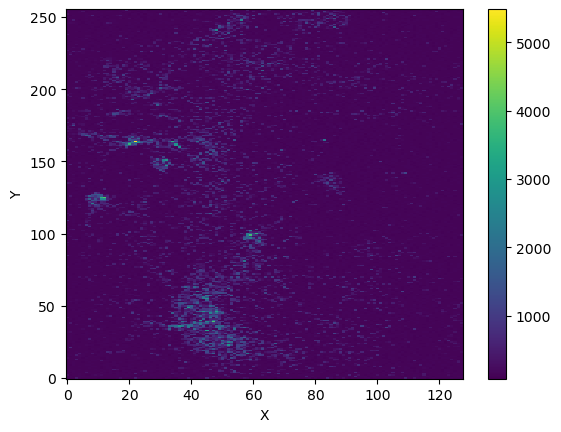

In [40]:
tiff.stack.sel(T=0, Z=3).plot()

In [35]:
tiff.length

411.55373199999997

In [32]:
tiff.stack.sizes['T']

2995

In [11]:
# View metadata
print(tiff.metadata['dimension_order'])
print(tiff.stack.shape)

TZCYX
(2995, 7, 1, 256, 128)


In [12]:
viewer = napari.Viewer()

viewer.add_image(tiff.stack,
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'],
                 name="full_stack")

viewer.add_image(tiff.stack.max(axis=1),
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'],
                 name='z_mip_stack')

napari.run()

c:\Users\ahshenas\miniforge3\envs\gulp2p\lib\site-packages\napari\layers\image\image.py:1300: RuntimeWarning: invalid value encountered in power
  downsampled = downsampled**self.gamma
c:\Users\ahshenas\miniforge3\envs\gulp2p\lib\site-packages\napari\layers\image\image.py:1300: RuntimeWarning: invalid value encountered in power
  downsampled = downsampled**self.gamma


## Trial

In [13]:
trial = utils.load_trial(tiff)

In [14]:
trial.get_synced_length()

359.1525769047439

In [15]:
trial.get_metadata_length()

411.55373199999997